In [1]:
import os
import sys
from pathlib import Path
import pandas as pd

sys.path.append("../")
from src.io import read_parameters


Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|██████████| 11/11 [00:00<00:00, 80.02it/s]

Numba compilation complete!


In [2]:
# read parameters and key file

parameter_file = "/home/jpa/PycharmProjects/ec-tracking-analysis_2025/data/collectivity/parameters_collectivity.yml"
parameters = read_parameters(parameter_file)       

key_file_path = parameters["key_file"]
key_file = pd.read_csv(key_file_path)

print("key file columns:", key_file.columns)
print("key file conditions:", key_file["condition"].unique())

key file columns: Index(['experimentID', 'filename', 'color', 'treatment', 'condition',
       'frame_per_hour', 'date'],
      dtype='object')
key file conditions: ['Flow']


In [3]:
# create output folder

output_folder = Path(parameters["output_folder"])
print("Output folder:", output_folder)

data_folder = output_folder.joinpath("tracking_data")

subfolder = "time_graph_analysis"
if not os.path.exists(output_folder.joinpath(subfolder)):
    os.mkdir(output_folder.joinpath(subfolder))


Output folder: /home/jpa/PycharmProjects/ec-tracking-analysis_2025/data/collectivity/collectivityquestion_results


In [4]:
# plot paramters

#condition = 'mosaic_siCTRL_siAlk1'
#condition = 'mosaic_siCTRL_siSMAD4'
# color = 'red'
#treatment = 'siAlk1'

#number_of_tracks_per_condition = 1000

observation_time = parameters["observation_time"]

# limits for min velocity and max velocity in um/h used for the color map
min_vel_lim = -20.0 # um/h
max_vel_lim = 20.0 # um/h

# extend in microns of the coordinate system used for plotting, 
# range is [-max_x, max_x] in x direction and [-max_y, max_y] in y direction
max_x = 600 # um
max_y = 600 # um

obs_time_length_frames = observation_time[1] - observation_time[0]

print("Observation time (frames):", observation_time)

plot_tracks = False
plot_arrows = True

distance_threshold = parameters.get("distance_threshold", 50) # um, default value if not specified in parameters

Observation time (frames): [0, 50]


In [5]:
num_subsample = 5

In [6]:

import networkx as nx
from griottes import generate_delaunay_graph

graphs = {}
observation_period_dfs = {}
# loop over all experiments of this condition
for experimentID in key_file["experimentID"].unique():
    print("Processing experiment:", experimentID)

    # can only be one entry
    key_exp = key_file[key_file["experimentID"] == experimentID]

    row = key_exp.iloc[0]
    treatment = row["treatment"]

    tracking_file = "tracking_data_%s_%s_%s.csv" % (treatment, row["color"], row["experimentID"])
    data = pd.read_csv(str(data_folder.joinpath(tracking_file)), low_memory=False)

    # filter data for observation period
    observation_period_df = data[data["FRAME"] <= observation_time[1]]
    observation_period_df = observation_period_df[observation_period_df["FRAME"] >= observation_time[0]]
    observation_period_dfs[experimentID] = observation_period_df

    # rename columns for G_delaunay graph generation
    observation_period_df_exp = observation_period_df.rename(columns={"POSITION_X": "x", "POSITION_Y": "y"})
    # add "label" column
    observation_period_df_exp["label"] = observation_period_df_exp["TRACK_ID"]

    t_graphs = []

    # build G_delaunay graph per point in time
    for t in range(observation_time[0], observation_time[1]):
        observation_period_df_exp_id_t = observation_period_df_exp[observation_period_df_exp["FRAME"] == t].reset_index(drop=True)

        #print(observation_period_df_exp_id_t[["FRAME", "TRACK_ID", "label"]].head())

        print("Generating graph at time point %d ..." % t)
        G_delaunay = generate_delaunay_graph(
            observation_period_df_exp_id_t[observation_period_df_exp_id_t.columns],
            descriptors=observation_period_df_exp_id_t.columns,
            distance=distance_threshold,
            image_is_2D=True
        )
        print("Graph generated!")

        # relabel nodes to TRACK_IDs
        mapping = {n: G_delaunay.nodes[n]["TRACK_ID"] for n in G_delaunay.nodes}
        G_delaunay = nx.relabel_nodes(G_delaunay, mapping)

        t_graphs.append(G_delaunay)

    # store graphs for this experiment
    graphs[experimentID] = t_graphs

Processing experiment: S1_rep1
Generating graph at time point 0 ...
Graph generated!
Generating graph at time point 1 ...
Graph generated!
Generating graph at time point 2 ...
Graph generated!
Generating graph at time point 3 ...
Graph generated!
Generating graph at time point 4 ...
Graph generated!
Generating graph at time point 5 ...
Graph generated!
Generating graph at time point 6 ...
Graph generated!
Generating graph at time point 7 ...
Graph generated!
Generating graph at time point 8 ...
Graph generated!
Generating graph at time point 9 ...
Graph generated!
Generating graph at time point 10 ...
Graph generated!
Generating graph at time point 11 ...
Graph generated!
Generating graph at time point 12 ...
Graph generated!
Generating graph at time point 13 ...
Graph generated!
Generating graph at time point 14 ...
Graph generated!
Generating graph at time point 15 ...
Graph generated!
Generating graph at time point 16 ...
Graph generated!
Generating graph at time point 17 ...
Graph 


--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 916.0 to 951.0
Y range (μm): 999.0 to 1017.0
Total displacement (μm): 5.1
Average neighbors per frame: nan
-----------------------------------



/home/jpa/Programs/micromamba/envs/ec-track/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/jpa/Programs/micromamba/envs/ec-track/lib/python3.13/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


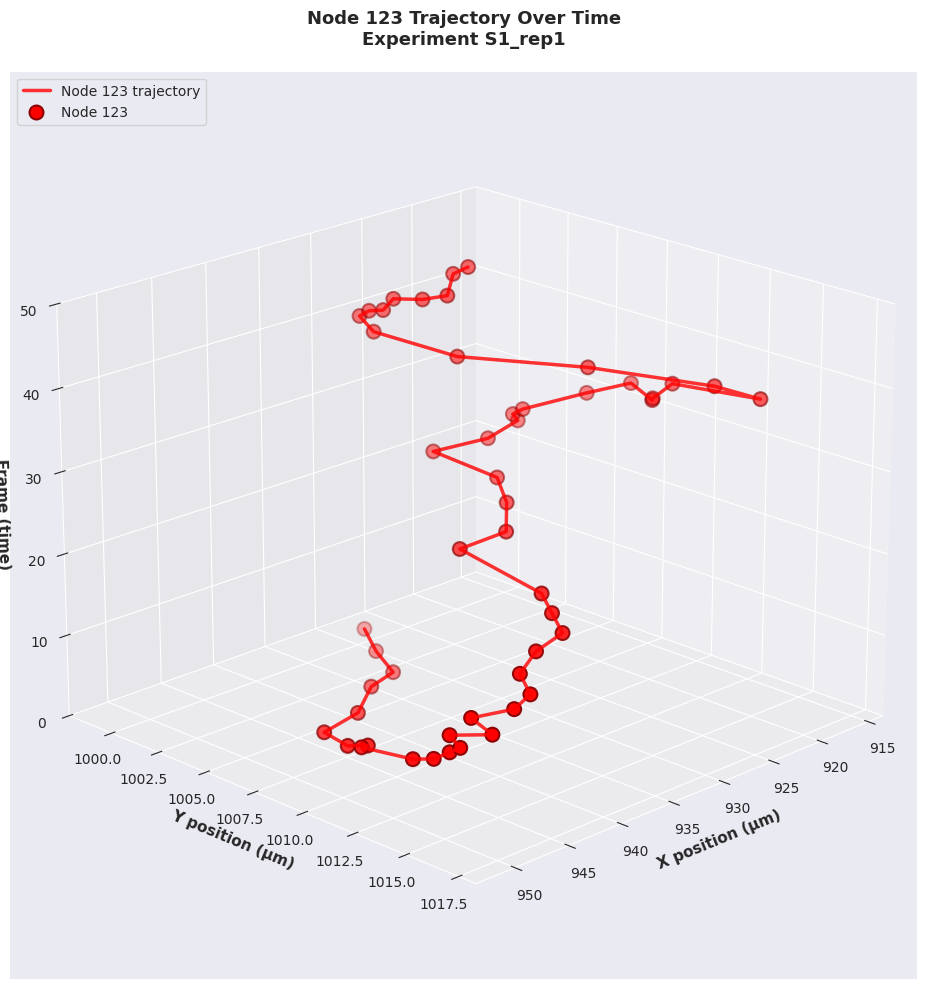


--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 2025.0 to 2102.0
Y range (μm): 2378.0 to 2396.0
Total displacement (μm): 77.4
Average neighbors per frame: nan
-----------------------------------



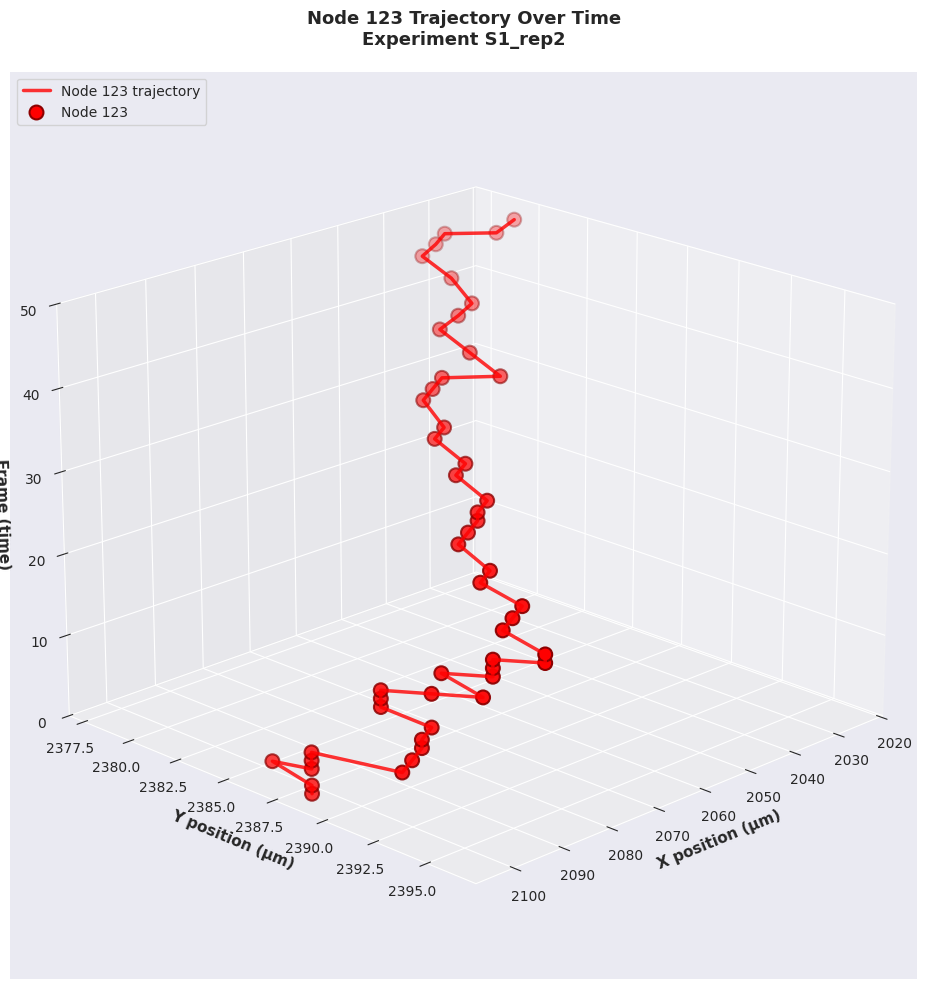


--- Node 123 Trajectory Summary ---
Number of timepoints: 38
Time range (frames): 0 to 37
X range (μm): 2232.0 to 2286.0
Y range (μm): 760.5 to 782.5
Total displacement (μm): 52.0
Average neighbors per frame: 0.0
-----------------------------------



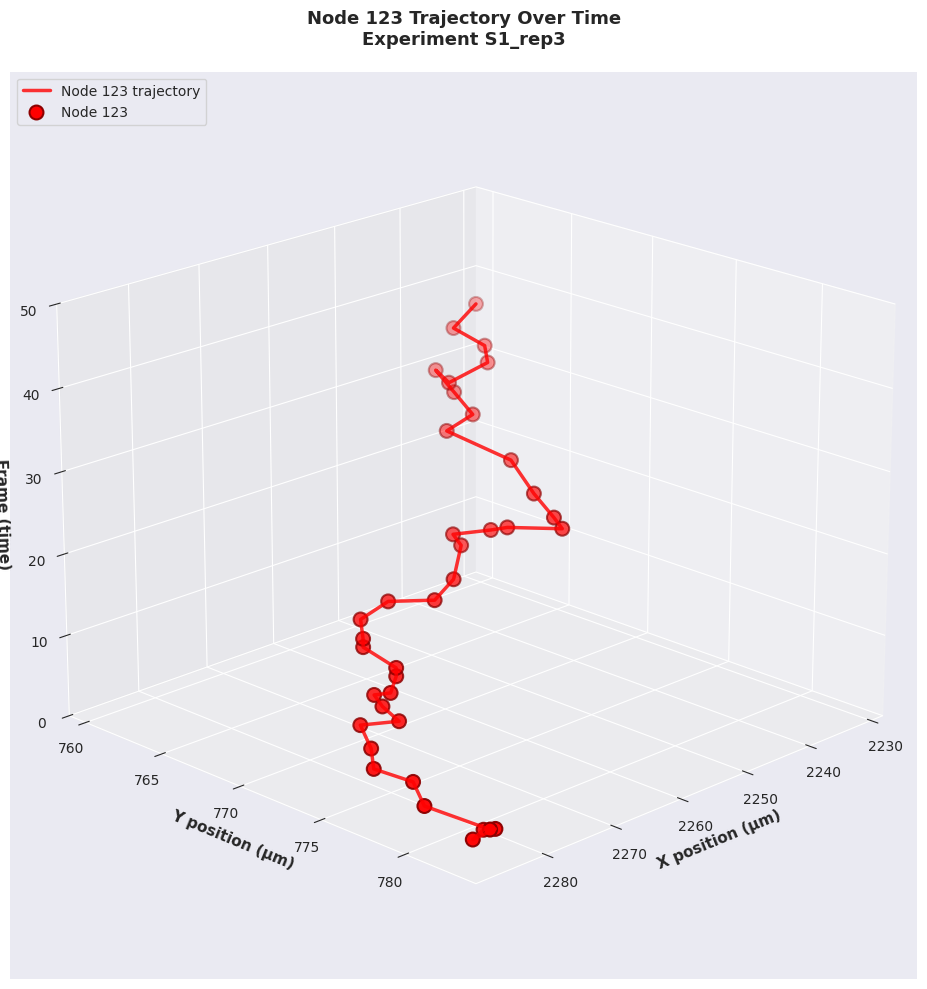


--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 1478.0 to 1557.0
Y range (μm): 281.2 to 295.0
Total displacement (μm): 28.2
Average neighbors per frame: nan
-----------------------------------



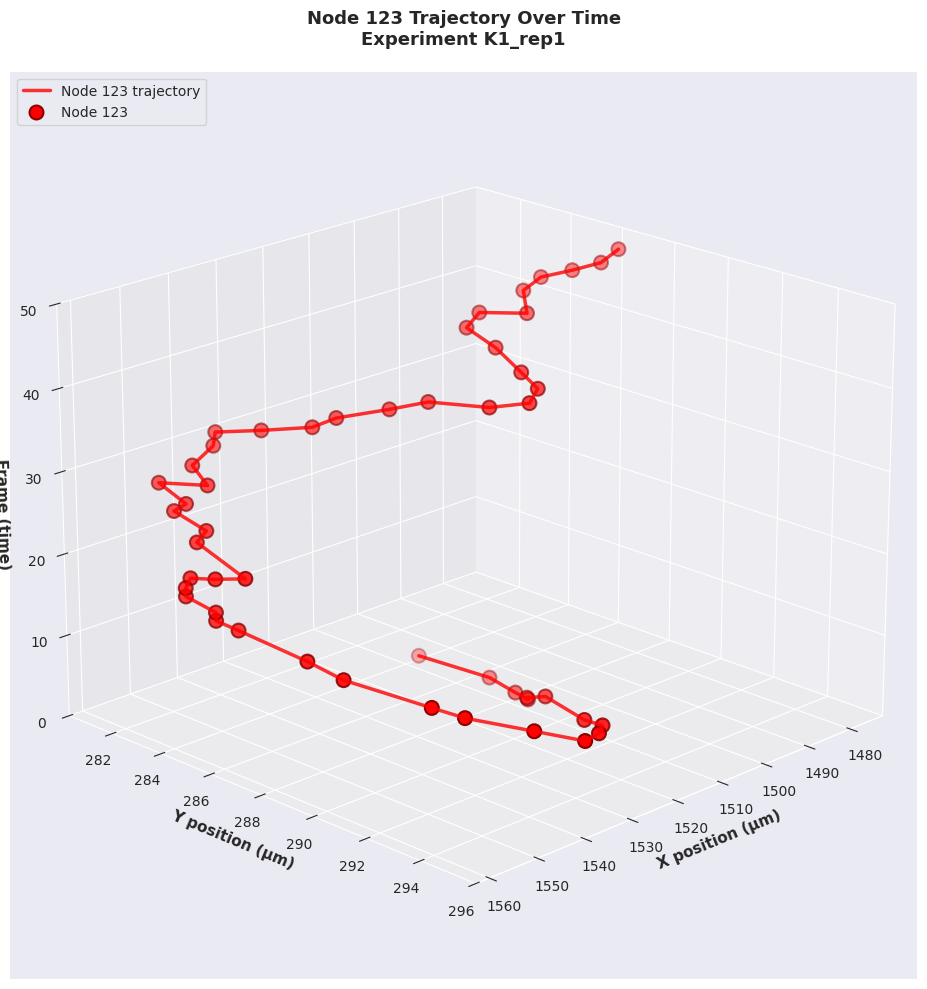


--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 2586.0 to 2624.0
Y range (μm): 112.6 to 176.0
Total displacement (μm): 66.7
Average neighbors per frame: nan
-----------------------------------



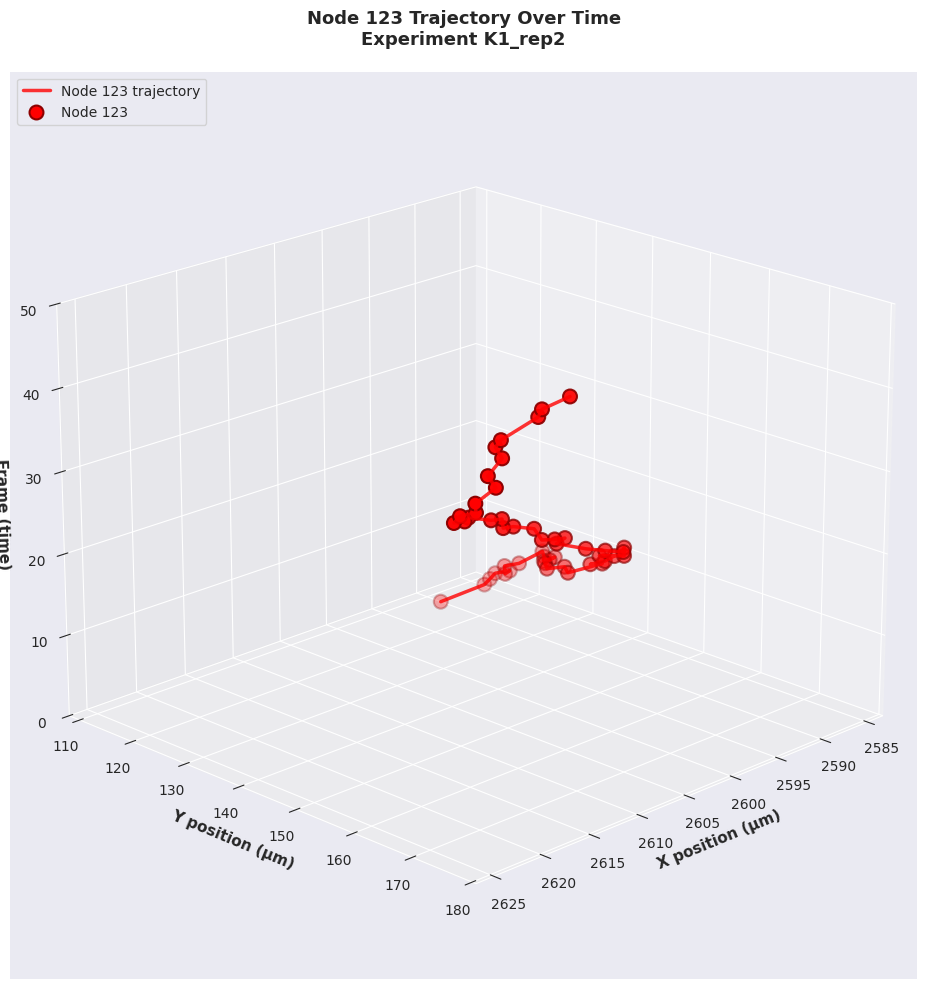


--- Node 123 Trajectory Summary ---
Number of timepoints: 50
Time range (frames): 0 to 49
X range (μm): 483.8 to 585.0
Y range (μm): 1175.0 to 1203.0
Total displacement (μm): 81.9
Average neighbors per frame: nan
-----------------------------------



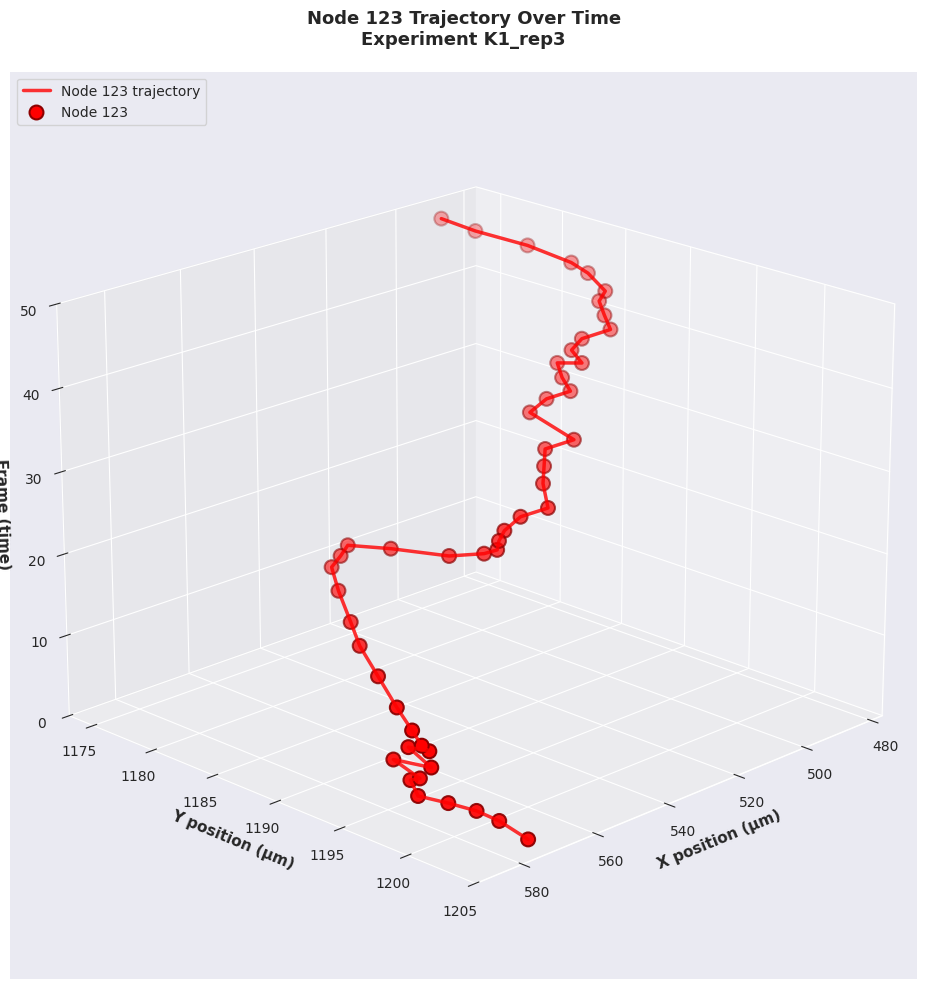

In [9]:
from matplotlib import pyplot as plt
from src.node_trajectory_viz import plot_node_trajectory_3d

# Choose a node ID to track (must be a TRACK_ID that exists in your graphs)
node_to_track = 123  # Replace with your desired node ID
for experimentID in key_file["experimentID"].unique():
    # Generate the visualization
    fig, ax = plot_node_trajectory_3d(
        node_id=node_to_track,
        graphs=graphs,                    # from your previous cell
        experimentID=experimentID,        # which experiment to visualize
        observation_time=observation_time, # frame range from parameters
        figsize=(14, 10),
        node_color='red',
        neighbor_color='lightblue',
        neighbor_alpha=0.35,
        trajectory_linewidth=2.5,
        show_neighbors=False,
    )

    plt.show()

In [8]:
neighbor_lifetimes_tracks_experiments = {}

# iterate over experiments
for experimentID in key_file["experimentID"].unique():
    print("Analyzing experiment with id:", experimentID)
    observation_period_df = observation_period_dfs[experimentID]

    # sample a subset of tracks from tracking file for faster computation
    trackIDs = observation_period_df["TRACK_ID"].unique()

    # iterate over time graphs
    t_graphs = graphs[experimentID]

    # dictionary to hold neighbor lifetimes for all sampled tracks
    neighbor_lifetimes_tracks = {}

    # iterate over sampled tracks
    for track_id in trackIDs:
        neighbor_lifetimes = {}

        # first time point
        t_graphs0 = t_graphs[0]

        if track_id not in t_graphs0.nodes(data="TRACK_ID"):
            print("Track ID %d not present at first time point, skipping..." % track_id)
            continue

        neighbors0 = list(t_graphs0.neighbors(track_id))
        #print("Track ID %d at time 0 has neighbors: %s" % (track_id, neighbors0))

        for neighbor in neighbors0:
            neighbor_lifetimes[neighbor] = 1 # initialize lifetimes at time 0

        # iterate over rest of time points
        for t, G_delaunay in enumerate(t_graphs[1:], start=1):

            # iterate
            node_track = [n for n, d in G_delaunay.nodes(data=True) if d.get("TRACK_ID") == track_id]
            if len(node_track) >1:
                print("Warning: Multiple nodes found for track ID %d at time %d" % (track_id, t))
            elif len(node_track) ==0:
                print("Track ID %d not present at time %d, skipping..." % (track_id, t))
                break

            a = node_track[0]
            neighbors_t = G_delaunay[a]

            # increment lifetime count for each observed neighbor
            for neighbor in neighbors_t:
                if neighbor in neighbor_lifetimes:
                    # increment only if consecutive
                    if neighbor_lifetimes[neighbor] == t:
                        #print("Track ID %d at time 0 had neighbors : %s" % (track_id, neighbors0))
                        #print("Track ID %d at time %d has neighbors: %s" % (track_id, t, neighbors_t))
                        #print("Persisting neighbor: %d at time %d" % (neighbor, t))
                        neighbor_lifetimes[neighbor] += 1
                        #print("Incremented lifetime of neighbor %d to %d" % (neighbor, neighbor_lifetimes[neighbor]))


        neighbor_lifetimes_tracks[track_id] = neighbor_lifetimes
    neighbor_lifetimes_tracks_experiments[experimentID] = neighbor_lifetimes_tracks


Analyzing experiment with id: S1_rep1
Track ID 2039 not present at time 27, skipping...
Track ID 4082 not present at time 27, skipping...
Track ID 3920 not present at time 30, skipping...
Track ID 2044 not present at time 37, skipping...
Track ID 3311 not present at time 28, skipping...
Track ID 3607 not present at time 30, skipping...
Track ID 1023 not present at time 48, skipping...
Track ID 2735 not present at time 34, skipping...
Track ID 752 not present at time 27, skipping...
Track ID 4025 not present at time 17, skipping...
Track ID 722 not present at time 48, skipping...
Track ID 2060 not present at time 40, skipping...
Track ID 3482 not present at time 6, skipping...
Track ID 3449 not present at time 34, skipping...
Track ID 3446 not present at time 35, skipping...
Track ID 3664 not present at time 31, skipping...
Track ID 2797 not present at time 31, skipping...
Track ID 2056 not present at time 33, skipping...
Track ID 779 not present at time 49, skipping...
Track ID 720 not

Experiment ID: S1_rep1
Sampled track IDs: [3955 1250 2412 2127 1791]
Edge lifetimes for track ID 3955: [8, 36, 1]


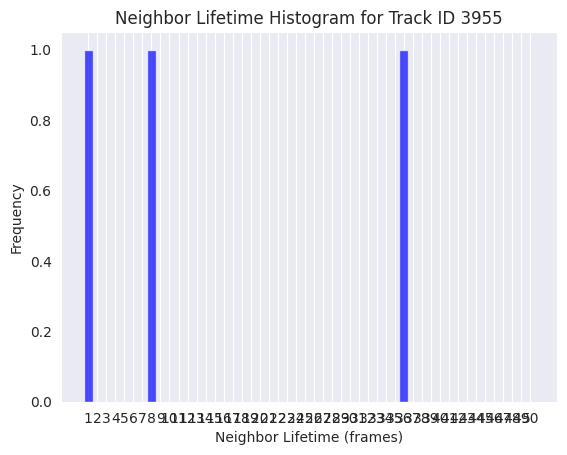

Edge lifetimes for track ID 1250: [18, 7]


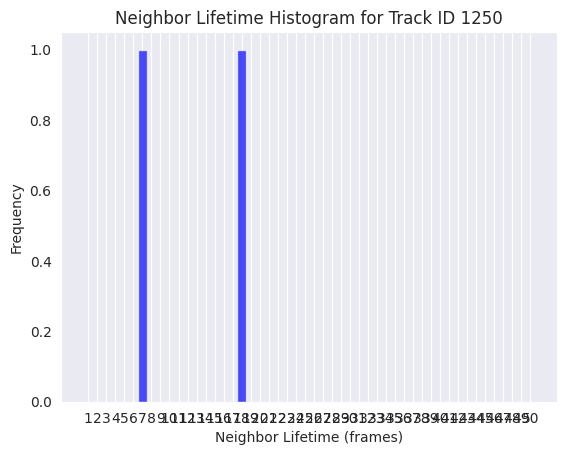

Edge lifetimes for track ID 2412: [3, 11, 21]


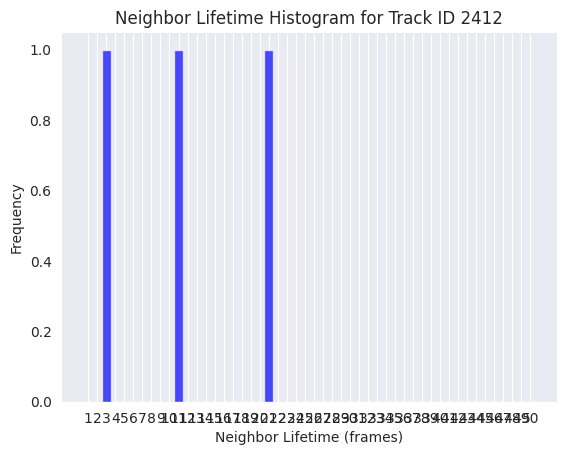

Edge lifetimes for track ID 2127: [3, 3, 1]


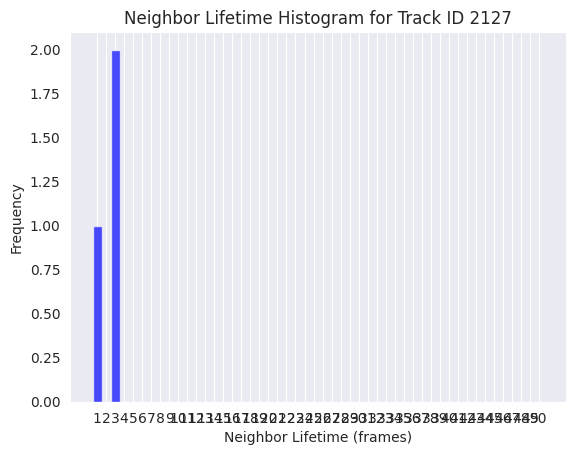

Edge lifetimes for track ID 1791: [2, 1, 13, 9, 10]


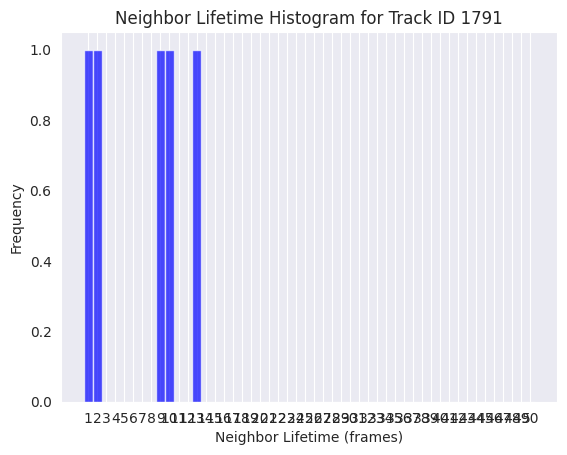

Experiment ID: S1_rep2
Sampled track IDs: [1619 4519 3179 1277 3114]
Edge lifetimes for track ID 1619: [15]


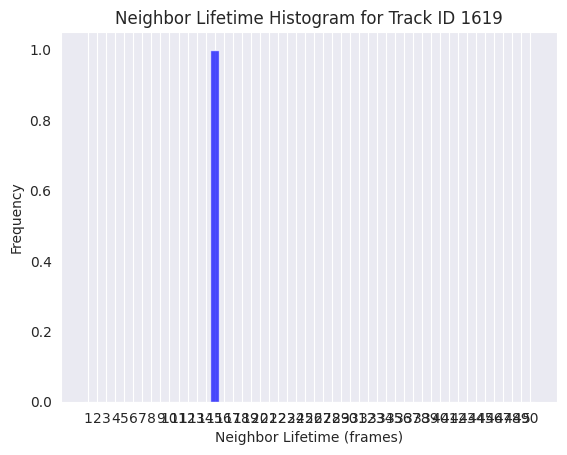

Edge lifetimes for track ID 4519: [17, 16, 2, 4]


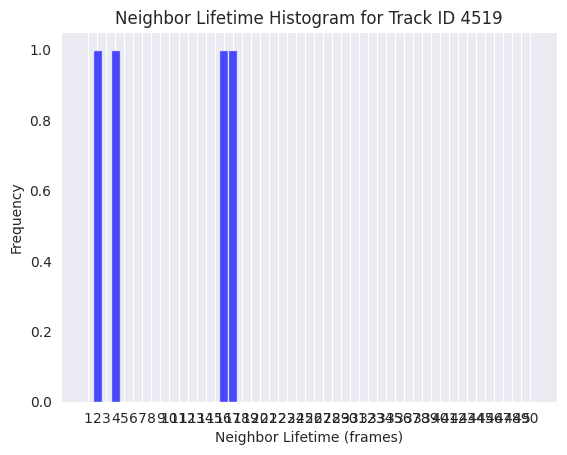

Edge lifetimes for track ID 3179: [21, 35]


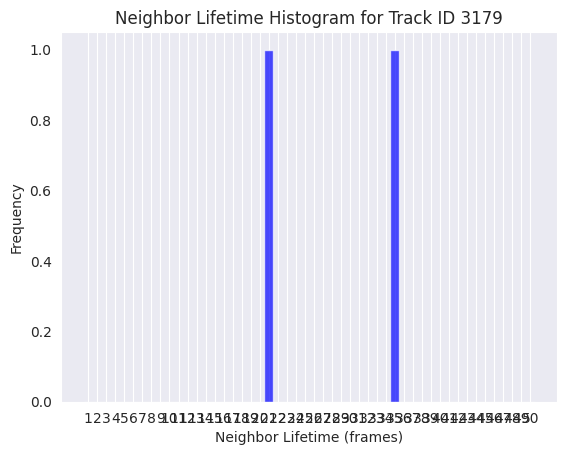

Edge lifetimes for track ID 1277: [36, 50, 20, 50]


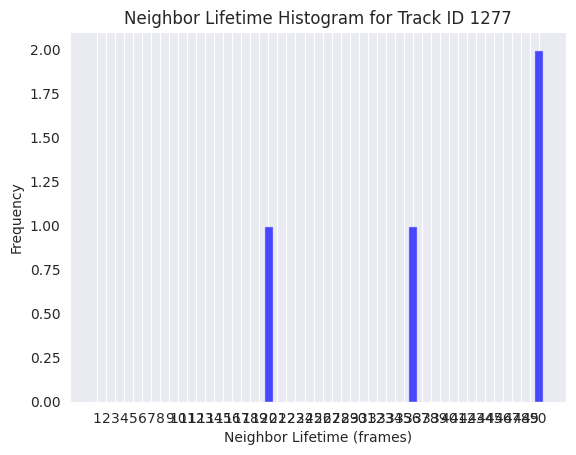

Edge lifetimes for track ID 3114: [15, 18, 18, 26]


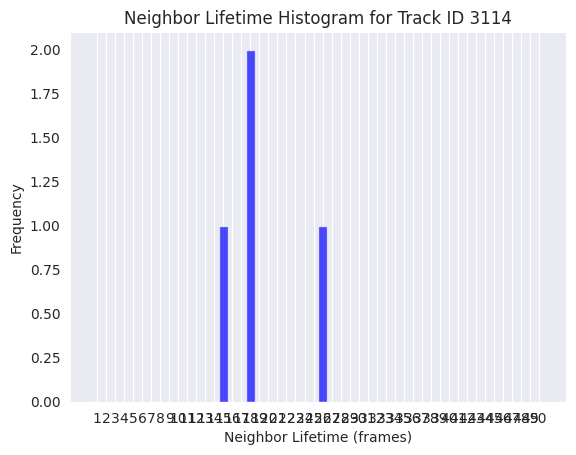

Experiment ID: S1_rep3
Sampled track IDs: [ 926 2922 1276 2246 3024]
Edge lifetimes for track ID 926: [6, 29, 24, 10, 8]


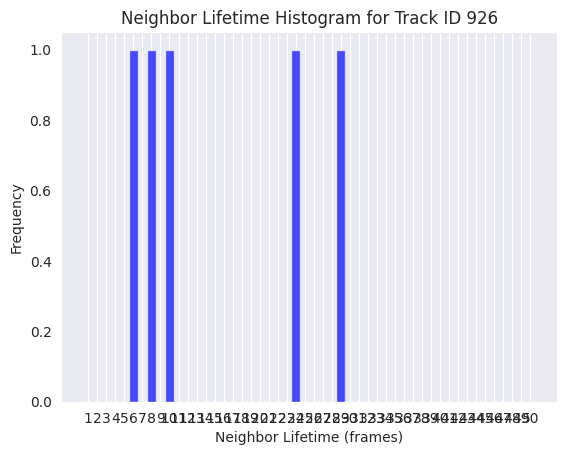

Edge lifetimes for track ID 2922: [50, 15, 44, 5, 1]


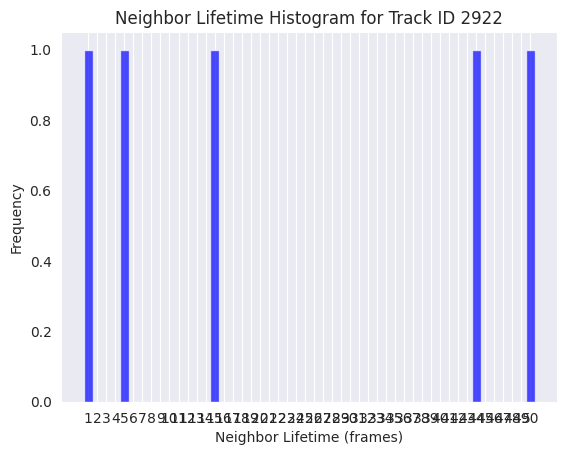

Edge lifetimes for track ID 1276: [17]


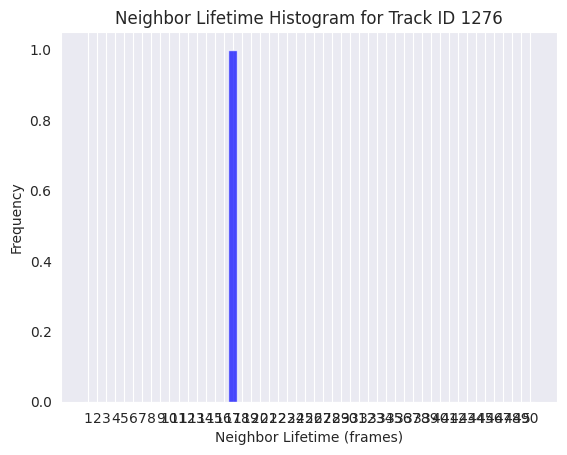

Edge lifetimes for track ID 2246: [14]


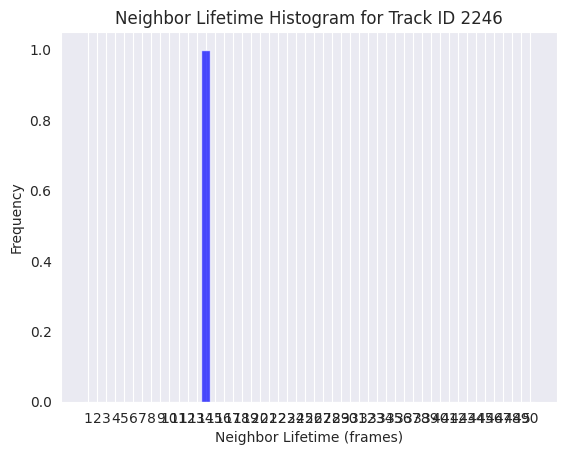

Edge lifetimes for track ID 3024: [50]


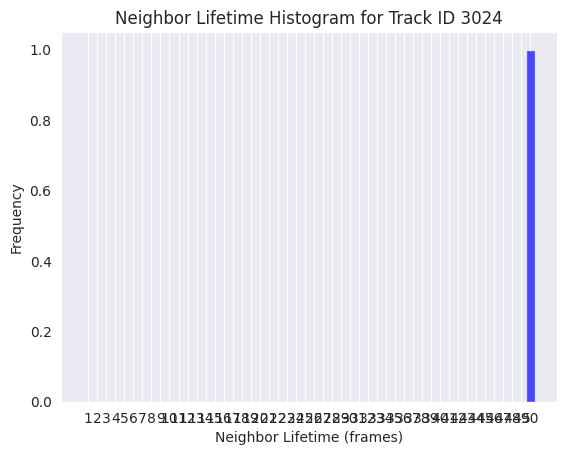

Experiment ID: K1_rep1
Sampled track IDs: [ 275 1040 1036  100  478]
Edge lifetimes for track ID 275: [24, 9]


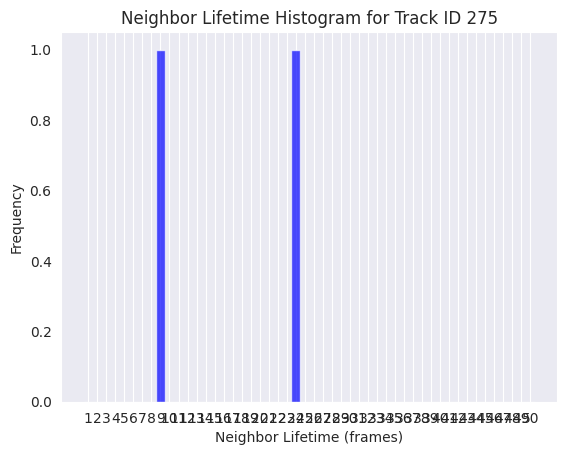

Edge lifetimes for track ID 1040: [28, 8, 24, 4]


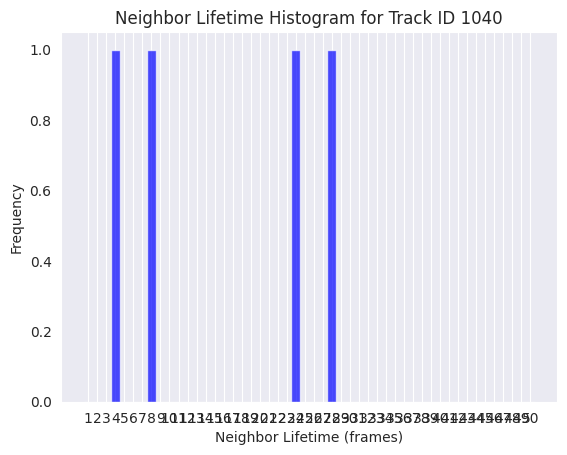

Edge lifetimes for track ID 1036: [50, 8]


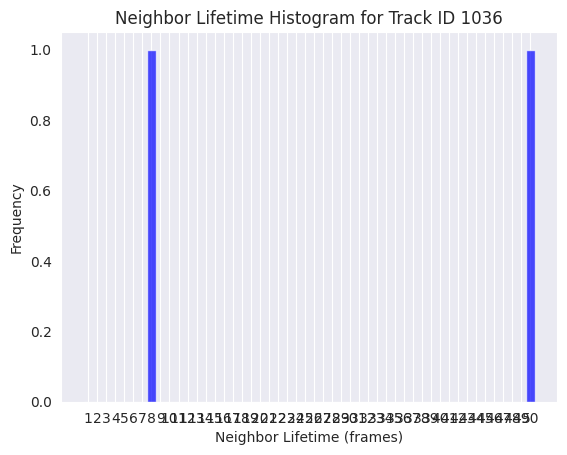

Edge lifetimes for track ID 100: [16]


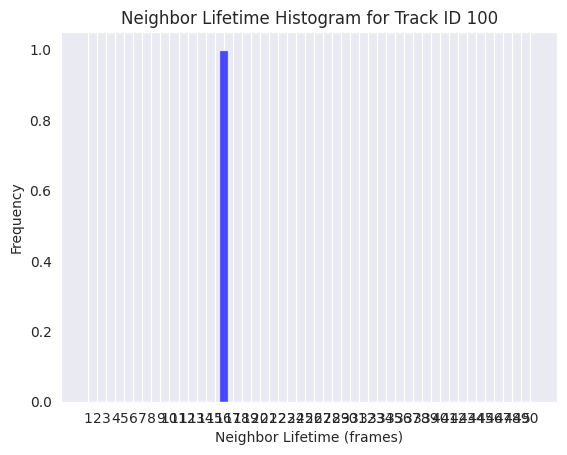

Edge lifetimes for track ID 478: [1, 12, 15]


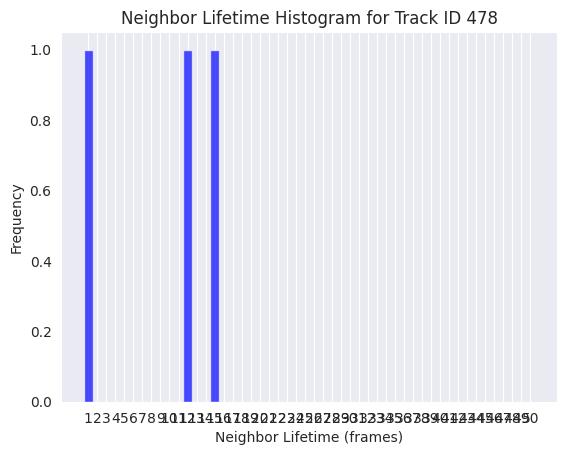

Experiment ID: K1_rep2
Sampled track IDs: [ 356 2783  605  140 2391]
Edge lifetimes for track ID 356: [24, 14]


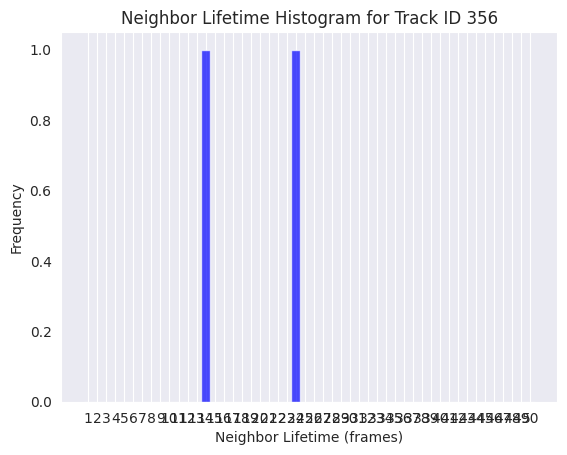

Edge lifetimes for track ID 2783: [12, 34, 34]


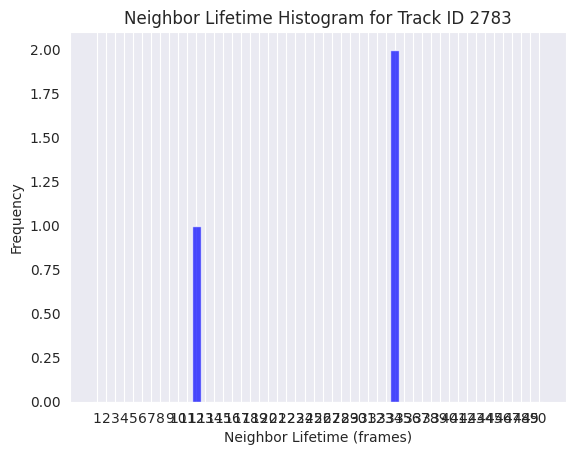

Edge lifetimes for track ID 605: [5, 21, 29, 2, 11, 4]


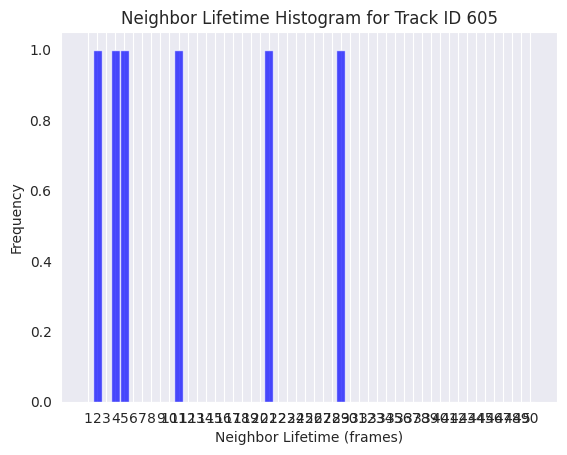

Edge lifetimes for track ID 140: [22, 16]


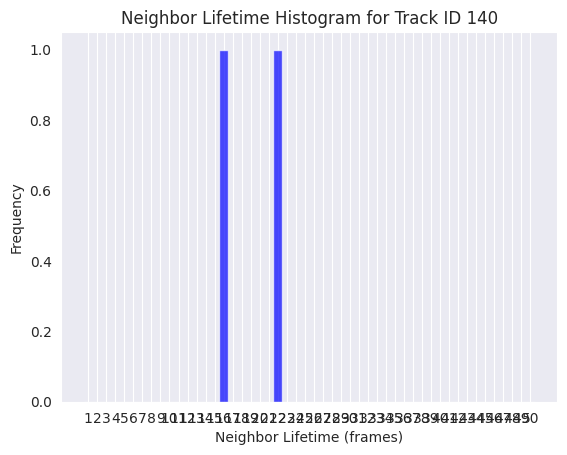

Edge lifetimes for track ID 2391: [7, 3, 1, 39]


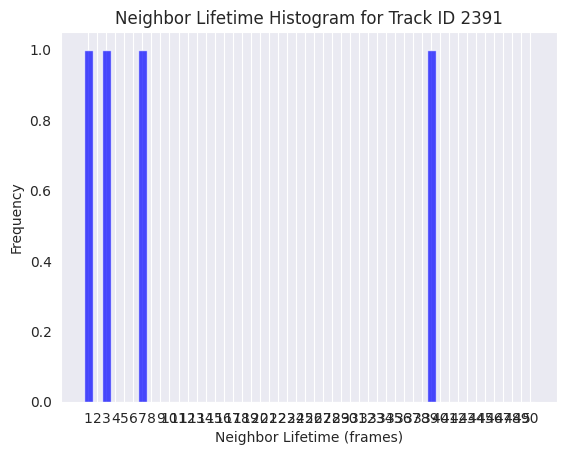

Experiment ID: K1_rep3
Sampled track IDs: [1948  309 2394 2245 2777]
Edge lifetimes for track ID 1948: [24, 50]


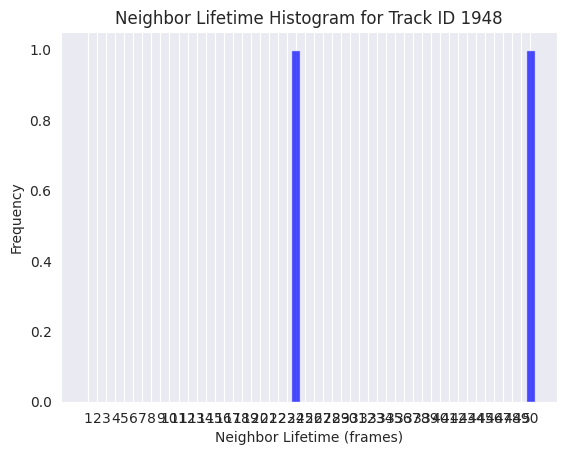

Edge lifetimes for track ID 309: [30, 30, 14, 30]


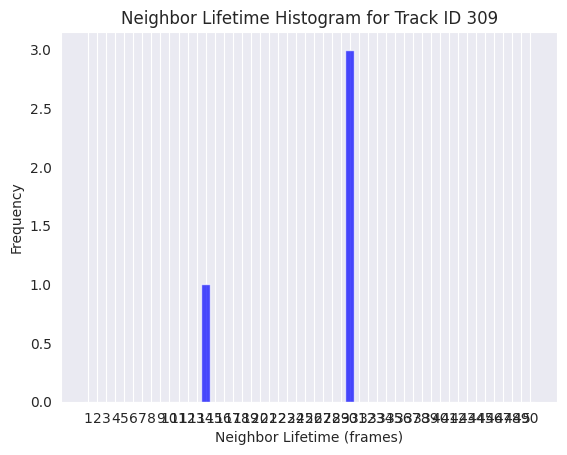

Edge lifetimes for track ID 2394: [20, 38, 9, 17]


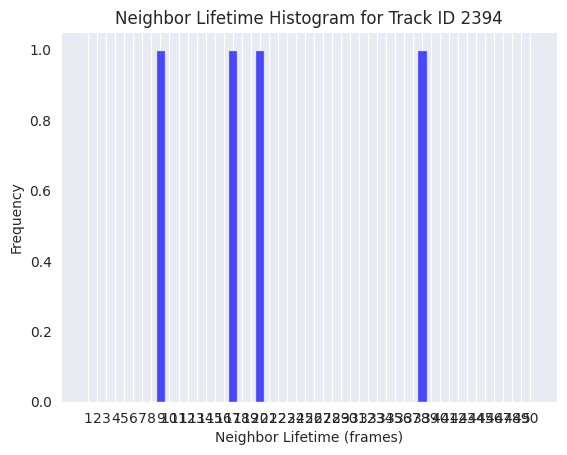

Edge lifetimes for track ID 2245: [2, 5, 50, 5]


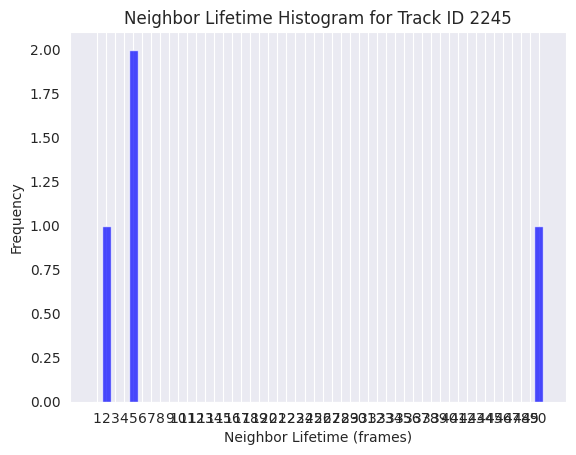

Edge lifetimes for track ID 2777: [25, 45, 5]


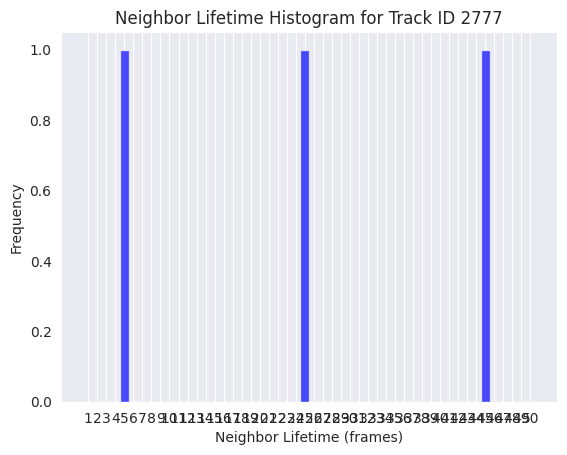

In [9]:
import numpy as np

# randomly sample some tracks and plot histograms of neighbor lifetimes
for experimentID in key_file["experimentID"].unique():
    print("Experiment ID:", experimentID)

    neighbor_lifetimes_tracks = neighbor_lifetimes_tracks_experiments[experimentID]

    trackIDs = list(neighbor_lifetimes_tracks.keys())

    if len(trackIDs) > num_subsample:
        sampled_trackIDs = np.random.choice(trackIDs, size=num_subsample, replace=False)
    else:
        sampled_trackIDs = trackIDs

    print("Sampled track IDs:", sampled_trackIDs)

    for track_id in sampled_trackIDs:
        neighbor_lifetimes = neighbor_lifetimes_tracks[track_id]

        lifetimes = list(neighbor_lifetimes.values())
        
        print(f"Edge lifetimes for track ID {track_id}:", lifetimes)

        plt.figure()
        plt.hist(lifetimes, bins=range(1, obs_time_length_frames + 2),
                 align='left', color='blue', alpha=0.7)
        plt.xlabel('Neighbor Lifetime (frames)')
        plt.ylabel('Frequency')
        plt.title(f'Neighbor Lifetime Histogram for Track ID {track_id}')
        plt.xticks(range(1, obs_time_length_frames + 1))
        plt.grid(axis='y')
        plt.show()

Experiment ID: S1_rep1
Mean Neighbor Lifetime: 14.95 frames
Median Neighbor Lifetime: 10.00 frames
Standard Deviation: 13.63 frames
Experiment ID: S1_rep2
Mean Neighbor Lifetime: 20.17 frames
Median Neighbor Lifetime: 16.00 frames
Standard Deviation: 15.86 frames
Experiment ID: S1_rep3
Mean Neighbor Lifetime: 18.03 frames
Median Neighbor Lifetime: 14.00 frames
Standard Deviation: 14.89 frames
Experiment ID: K1_rep1
Mean Neighbor Lifetime: 17.19 frames
Median Neighbor Lifetime: 13.00 frames
Standard Deviation: 14.42 frames
Experiment ID: K1_rep2
Mean Neighbor Lifetime: 18.62 frames
Median Neighbor Lifetime: 14.00 frames
Standard Deviation: 15.11 frames
Experiment ID: K1_rep3
Mean Neighbor Lifetime: 18.07 frames
Median Neighbor Lifetime: 14.00 frames
Standard Deviation: 14.45 frames


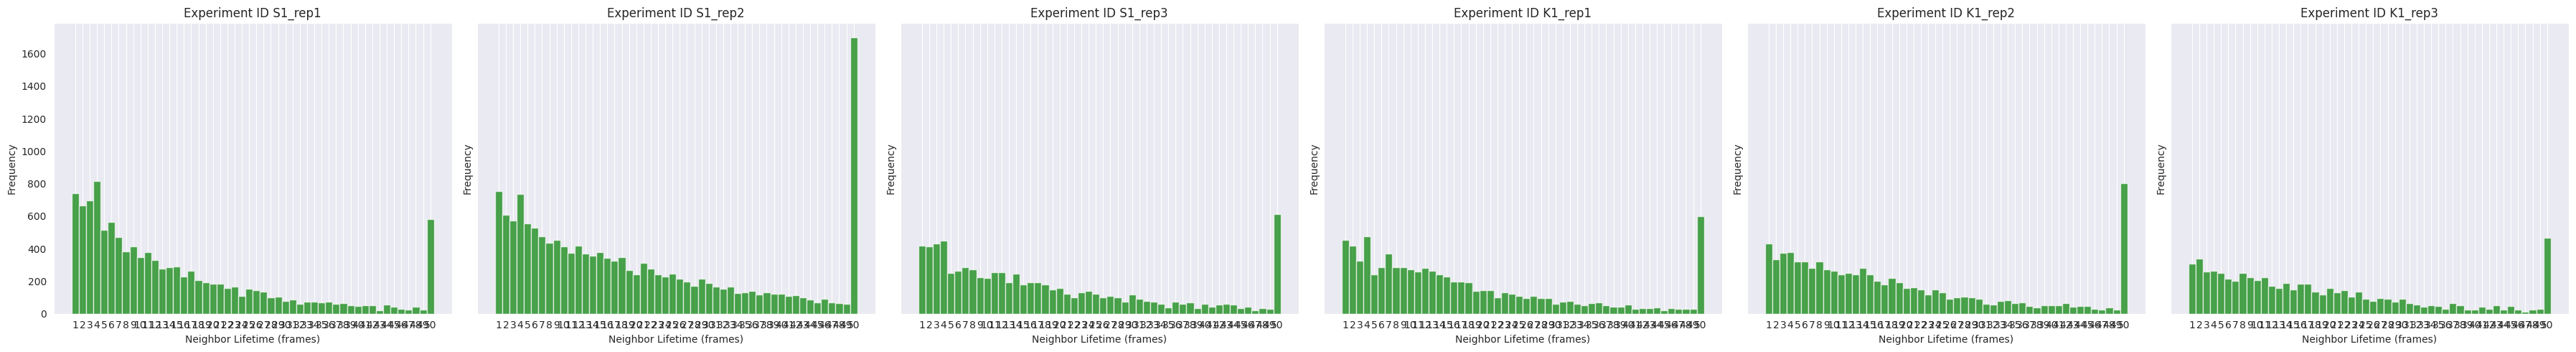

In [10]:
# summary stats of neighbor lifetimes across all tracks
experiment_ids = key_file["experimentID"].unique()

# Prepare a single row of subplots
n_experiments = len(experiment_ids)
fig, axes = plt.subplots(1, n_experiments, figsize=(6 * n_experiments, 5), sharey=True)

if n_experiments == 1:
    axes = [axes]  # ensure axes is iterable even for a single experiment

for ax, experimentID in zip(axes, experiment_ids):
    print("Experiment ID:", experimentID)

    neighbor_lifetimes_tracks = neighbor_lifetimes_tracks_experiments[experimentID]

    all_lifetimes = []
    for track_id, neighbor_lifetimes in neighbor_lifetimes_tracks.items():
        lifetimes = list(neighbor_lifetimes.values())
        all_lifetimes.extend(lifetimes)

    if all_lifetimes:
        mean_lifetime = np.mean(all_lifetimes)
        median_lifetime = np.median(all_lifetimes)
        std_lifetime = np.std(all_lifetimes)

        print(f"Mean Neighbor Lifetime: {mean_lifetime:.2f} frames")
        print(f"Median Neighbor Lifetime: {median_lifetime:.2f} frames")
        print(f"Standard Deviation: {std_lifetime:.2f} frames")

        # plot histogram in its subplot
        ax.hist(all_lifetimes, bins=range(1, obs_time_length_frames + 2),
                align='left', color='green', alpha=0.7)
        ax.set_xlabel('Neighbor Lifetime (frames)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'Experiment ID {experimentID}')
        ax.set_xticks(range(1, obs_time_length_frames + 1))
        ax.grid(axis='y')

    else:
        print("No neighbor lifetimes recorded for this experiment.")
        ax.set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# neighborhood consistency as a heatmap (tracks × time) to identify locally unstable areas